In [1]:
import os

if "GROQ_API_KEY" not in os.environ:
    raise EnvironmentError("GROQ_API_KEY environment variable is not set.")

In [2]:
#Now llm setup
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage

llm = ChatGroq(model="llama-3.1-8b-instant", temperature=0.5)
response = llm.invoke([HumanMessage(content="What is the capital of France?")]).content
print(response)


The capital of France is Paris.


Create Graph Schema


In [24]:
from typing import TypedDict,List,Annotated
from operator import add
class Graph_Schema(TypedDict):
    message_manual : List[HumanMessage]
    message_auto : Annotated[List, add]



Create Node

In [33]:
from langchain_core.messages import AIMessage

def create_post(state: Graph_Schema) -> Graph_Schema:
    #extraact the message_manual list from the state
    message_manual = state["message_manual"]
    

    #invoke to llm to generate a new message
    response_manual = llm.invoke(message_manual).content

    response_manual_ai = AIMessage(content=response_manual)

    #append the ai message to the message_manual list
    state["message_manual"] = message_manual + [response_manual_ai]

    return state


def create_curated_post(state: Graph_Schema) -> Graph_Schema:
    #extraact the message_manual list from the state
    message_manual = state["message_manual"]

    response_manual = llm.invoke(message_manual).content

    response_manual_ai = AIMessage(content=response_manual)

    state["message_manual"] = message_manual + [response_manual_ai]

    return state

Create Graph nodes and Edges

In [35]:
from langgraph.graph import StateGraph,START, END

graph = StateGraph(Graph_Schema)

graph.add_node("create_post", create_post)
graph.add_node("create_curated_post", create_curated_post)

#Add egdes to the graph
graph.add_edge(START,"create_post")
graph.add_edge("create_post","create_curated_post")
graph.add_edge("create_curated_post",END)

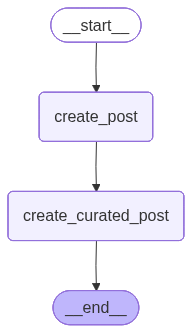

In [36]:
from IPython.display import display,Image

message_graph = graph.compile()
Image(message_graph.get_graph().draw_mermaid_png())


In [37]:
message_graph.invoke(
    {"message_manual": [HumanMessage(content="Tell me about the latest ai Tech")] }
)

{'message_manual': [HumanMessage(content='Tell me about the latest ai Tech', additional_kwargs={}, response_metadata={}),
  AIMessage(content="The latest AI technology is rapidly evolving and has numerous advancements in various fields. Here are some of the key developments:\n\n1. **Large Language Models (LLMs):** LLMs are AI models that can process and generate human-like language. They have been trained on massive datasets and can perform tasks such as text generation, translation, summarization, and more. Examples of LLMs include:\n\t* **ChatGPT:** A conversational AI model that can engage in natural-sounding conversations.\n\t* **BERT (Bidirectional Encoder Representations from Transformers):** A pre-trained language model that has achieved state-of-the-art results in various NLP tasks.\n\t* **RoBERTa (Robustly Optimized BERT Pretraining Approach):** A variant of BERT that has improved performance on several NLP tasks.\n2. **Computer Vision:** AI models that can interpret and under